<a href="https://colab.research.google.com/github/Maryam-Skaik/student-performance-prediction/blob/main/notebook/student-performance-prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Habits vs Academic Performance

### Problem Description

This dataset explores how various lifestyle habits affect students' academic performance. The task is to predict final exam scores based on features like study hours, sleep patterns, social media usage, diet quality, mental health, etc.

### Target Variable:
Final Exam Score (Continuous, can also be converted to categories like "Fail", "Pass", "Excellent" for classification)

## Imports

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

from sklearn.inspection import permutation_importance

## Custom Functions

In [ ]:
def regression_metrics(y_true, y_pred, label='', verbose = True, output_dict=False):
  # Get metrics
  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  rmse = root_mean_squared_error(y_true, y_pred)
  r_squared = r2_score(y_true, y_pred)
  if verbose == True:
    # Print Result with Label and Header
    header = "-"*60
    print(header, f"Regression Metrics: {label}", header, sep='\n')
    print(f"- MAE = {mae:,.3f}")
    print(f"- MSE = {mse:,.3f}")
    print(f"- RMSE = {rmse:,.3f}")
    print(f"- R^2 = {r_squared:,.3f}")
  if output_dict == True:
      metrics = {'Label':label, 'MAE':mae, 'MSE':mse, 'RMSE':rmse, 'R^2':r_squared}
      return metrics

In [ ]:
def evaluate_regression(reg, X_train, y_train, X_test, y_test, verbose = True, output_frame=False):
  # Get predictions for training data
  y_train_pred = reg.predict(X_train)

  # Call the helper function to obtain regression metrics for training data
  results_train = regression_metrics(y_train, y_train_pred, verbose = verbose, output_dict=output_frame, label='Training Data')
  print()
  # Get predictions for test data
  y_test_pred = reg.predict(X_test)
  # Call the helper function to obtain regression metrics for test data
  results_test = regression_metrics(y_test, y_test_pred, verbose = verbose, output_dict=output_frame, label='Test Data' )

  # Store results in a dataframe if ouput_frame is True
  if output_frame:
    results_df = pd.DataFrame([results_train,results_test])
    # Set the label as the index
    results_df = results_df.set_index('Label')
    # Set index.name to none to get a cleaner looking result
    results_df.index.name=None
    # Return the dataframe
    return results_df.round(3)

## Load the Data

In [ ]:
fpath = '/content/drive/MyDrive/AXSOSACADEMY/02-MachineLearning/Practice/Data/student_habits_performance.csv'
df = pd.read_csv(fpath)
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


* **student_id**: Unique identifier for each student. **Not useful for prediction** since it doesn't influence the outcome.

* **age**: Student's age.

* **gender**: Gender of the student.

* **study_hours_per_day**: Daily study time in hours. **Important feature** as more study hours are likely to correlate with higher exam scores.

* **social_media_hours**: Time spent on social media per day in hours.
**Potentially negative influence**, as excessive social media use might distract from studying.

* **netflix_hours**: Time spent watching Netflix per day in hours. **Likely to have a negative correlation** with exam scores due to entertainment consumption.

* **part_time_job**: Whether the student has a part-time job. **Could be important**, but a job might either help or hinder performance based on time management.

* **attendance_percentage**: Percentage of classes attended. **Highly important feature**, as high attendance generally correlates with better understanding and higher exam scores.

* **sleep_hours**: Number of hours of sleep per night. **Important feature**—sleep quality is known to affect cognitive function and academic performance.

* **diet_quality**: Quality of the student's diet (Fair, Good, Poor). **Might have some influence**, as proper nutrition can impact mental focus and performance.

* **exercise_frequency**: Frequency of exercise. **Potentially positive impact**—regular exercise may help improve cognitive function and reduce stress.

* **parental_education_level**: Parental education level. **Potentially significant**; higher parental education might indicate a supportive environment, leading to better academic outcomes.

* **internet_quality**: Quality of the student's internet connection. **Indirect influence**; a good connection could support better online learning and access to resources.

* **mental_health_rating**: Rating of the student's mental health. **Important feature**; good mental health generally correlates with better focus and academic performance.

* **extracurricular_participation**: Whether the student participates in extracurricular activities. **May not directly affect exam scores**, though extracurriculars can aid in overall development and stress management.

* **exam_score**: **Target feature**—this is the variable we aim to predict based on other factors. The goal is to predict **exam scores** using the available features.

### Key Insights:

* **Goal**: Predict **exam_score** based on lifestyle habits, study habits, and personal factors. Some features may be correlated with better or worse academic performance, but the challenge is understanding how to weigh these influences.

In [ ]:
df = df.drop(columns=['student_id'])
df.head()

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1000 non-null   int64  
 1   gender                         1000 non-null   object 
 2   study_hours_per_day            1000 non-null   float64
 3   social_media_hours             1000 non-null   float64
 4   netflix_hours                  1000 non-null   float64
 5   part_time_job                  1000 non-null   object 
 6   attendance_percentage          1000 non-null   float64
 7   sleep_hours                    1000 non-null   float64
 8   diet_quality                   1000 non-null   object 
 9   exercise_frequency             1000 non-null   int64  
 10  parental_education_level       909 non-null    object 
 11  internet_quality               1000 non-null   object 
 12  mental_health_rating           1000 non-null   in

* **Dataset Size**: 1,000 rows and 15 columns.
* **Missing Values**: The **parental_education_level** feature has 91 missing values, requiring imputation.
* **Data Types**:

  * **Numeric**: Features like `age`, `study_hours_per_day`, `social_media_hours`, etc., are correctly numeric.
  * **Categorical**: Features like `gender`, `part_time_job`, `diet_quality`, etc., need encoding.
* **Data Quality**: No missing values except in **parental_education_level**.
* **Action Required**:

  * Impute missing data in **parental_education_level**.
  * Encode categorical features for model compatibility.

In [ ]:
df.describe().round(2)

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,20.50,3.55,2.51,1.82,84.13,6.47,3.04,5.44,69.60
std,2.31,1.47,1.17,1.08,9.40,1.23,2.03,2.85,16.89
min,17.00,0.00,0.00,0.00,56.00,3.20,0.00,1.00,18.40
25%,18.75,2.60,1.70,1.00,78.00,5.60,1.00,3.00,58.48
50%,20.00,3.50,2.50,1.80,84.40,6.50,3.00,5.00,70.50
75%,23.00,4.50,3.30,2.52,91.02,7.30,5.00,8.00,81.32
max,24.00,8.30,7.20,5.40,100.00,10.00,6.00,10.00,100.00


* **No Unrealistic or Outlier Values**: Based on the statistics, all features seem to have reasonable values without extreme outliers.
* **Age**:

  * Range: 17 to 24 years.
* **Study Hours per Day**:

  * Range: 0 to 8.3 hours.
* **Social Media Hours**:

  * Range: 0 to 7.2 hours.
* **Netflix Hours**:

  * Range: 0 to 5.4 hours.
* **Attendance Percentage**:

  * Range: 56% to 100%.
* **Sleep Hours**:

  * Range: 3.2 to 10 hours.
* **Exercise Frequency**:

  * Range: 0 to 6.
* **Mental Health Rating**:

  * Range: 1 to 10.
* **Exam Score**:

  * Range: 18.4 to 100.

## Duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

No duplicated rows in dataset

## Missing Values Check

In [ ]:
df.isnull().sum()

,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0
exercise_frequency,0


* **Missing Data**: As noted from `df.info`, the **parental_education_level** feature has **91 missing values**.
* I will impute the missing values in **parental_education_level** using the **most frequent value (mode)** before building the model to ensure all features are complete.

## Data Cleaning and Feature Engineering

In [ ]:
for col in df.select_dtypes(include='object'):
    print(col, df[col].unique())

gender ['Female' 'Male' 'Other']
part_time_job ['No' 'Yes']
diet_quality ['Fair' 'Good' 'Poor']
parental_education_level ['Master' 'High School' 'Bachelor' nan]
internet_quality ['Average' 'Poor' 'Good']
extracurricular_participation ['Yes' 'No']


## Exploratory Data Analysis (EDA)

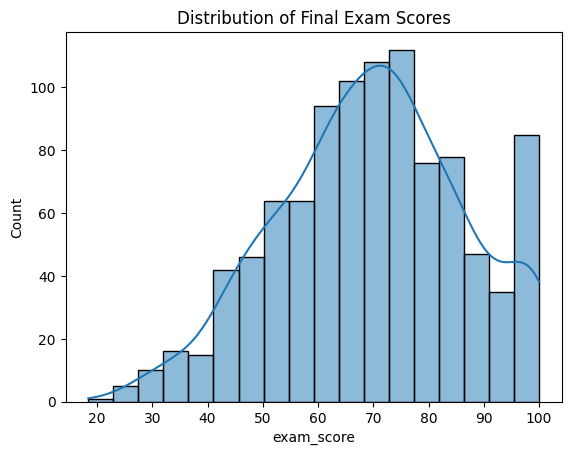

In [ ]:
# Distribution of final exam scores
sns.histplot(df['exam_score'], kde=True)
plt.title('Distribution of Final Exam Scores')
plt.show()

### Key Insights from Exam Score Distribution:

* **Distribution Shape**:

  * **Left-Skewed**: Most students scored well, but a few lower scores pulled the mean down.
  * **Peak Performance**: The most frequent scores (mode) are between **70 and 80**.

* **Key Trends**:

  * **High Passing Rates**: Most students scored above 60, with a concentration between **60 and 85**, suggesting a fair exam or good preparation.
  * **Perfect Scores**: There's a noticeable spike at **100**, indicating a group of high achievers or a ceiling effect.
  * **Lower Scores**: Very few students scored below 40, meaning few failed significantly.

* **Statistical Estimates**:

  * **Range**: From **20 to 100**.
  * **Typical Scores**: Most students scored between **72–75**.
  * **Performance Spread**: The middle 50% of students likely scored between **55 and 85**

### Conclusion:

The distribution shows a healthy spread, with most students performing well (C+ to B range). The left skew and peak at 100 suggest the exam differentiated between average and top performers, with only a small number of students struggling.

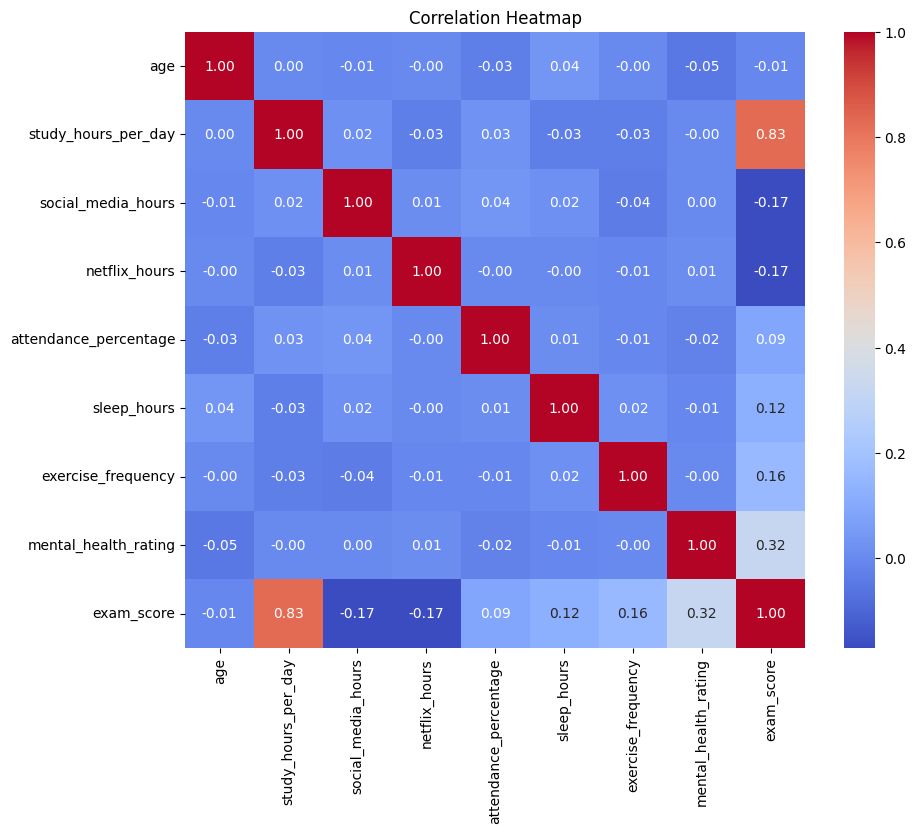

In [ ]:
# Correlation heatmap to understand relationships between features
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True).round(2), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### Key Insights from Correlation Heatmap:

* **Strongest Predictor**:

  * **Study Hours (0.83)**: A very strong positive correlation with exam scores. The more hours students spend studying, the better their performance.

* **Moderate Impact Factors**:

  * **Mental Health Rating (0.32)**: Moderate positive correlation; better mental health is linked to higher exam scores.
  * **Exercise Frequency (0.16)** & **Sleep Hours (0.12)**: Slight positive correlations, indicating physical well-being contributes to performance.

* **Negative Influences**:

  * **Social Media (-0.17)** & **Netflix Hours (-0.17)**: Both show weak negative correlations with exam scores, suggesting that time spent on these platforms slightly reduces performance.

* **Non-Factors**:

  * **Age (-0.01)**: Almost no correlation with exam scores or other features.
  * **Attendance Percentage (0.09)**: Very weak correlation, indicating attendance might not be as important as how students study.

### Summary:

If building a predictive model, **study hours** should be the primary feature. While **mental health**, **exercise**, and **sleep** play roles, their impact is secondary. Time spent on distractions like **social media** and **Netflix** negatively affects performance.

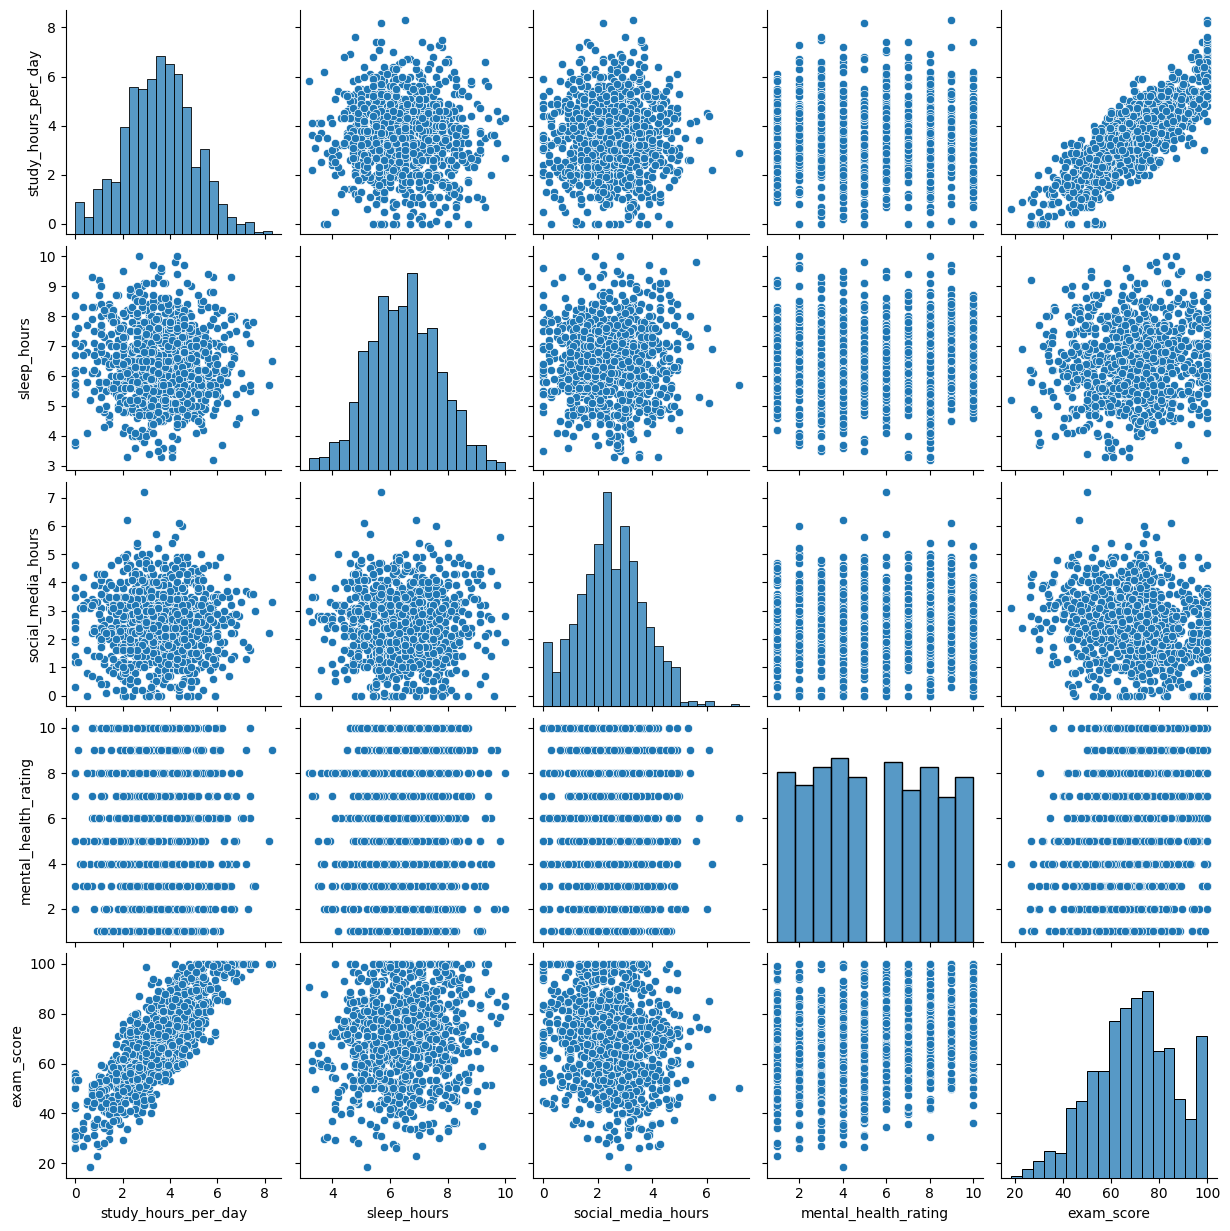

In [ ]:
# Visualizing relationships between key variables
sns.pairplot(df[['study_hours_per_day', 'sleep_hours', 'social_media_hours', 'mental_health_rating', 'exam_score']])
plt.show()

### Key Insights from Pair Plots:

* **Linearity vs. Randomness**:

  * **Study Hours vs. Exam Score**: The plot shows a **strong linear relationship**, confirming that more study hours are associated with higher exam scores.
  * **Sleep Hours vs. Social Media Hours**: The plot shows a **random cloud of dots**, indicating **no correlation** between sleep and social media usage.

* **Distribution Insights (Diagonals)**:

  * **Normal-ish Distributions**: `study_hours_per_day` and `sleep_hours` follow a bell-curve, with most students clustering around the average (4 hours of study, 7 hours of sleep).
  * **Mental Health Rating**: The distribution is **uniform**, showing a wide range of mental health scores.
  * **Exam Score**: The distribution is **right-skewed**, indicating that most students scored well.

* **Interesting Observations**:

  * **Ceiling Effects**: In the `exam_score` vs. `study_hours` plot, scores hit a **maximum at 100**, showing a ceiling effect.
  * **Social Media "Limit"**: The `social_media_hours` histogram shows a **sharp drop-off after 5-6 hours**, with very few students spending more than 6 hours on social media.

### Summary Table: Relationship Strength

| Relationship                | Visual Pattern          | Analysis           |
| --------------------------- | ----------------------- | ------------------ |
| **Study Hours vs. Score**   | Tight Diagonal          | Strong Predictor   |
| **Mental Health vs. Score** | Loose Vertical Clusters | Moderate Predictor |
| **Sleep vs. Social Media**  | Large Circular Cloud    | No Relationship    |

## Train-Test Split

In [ ]:
y = df['exam_score']
X = df.drop(columns=['exam_score'])

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

## Preprocessing

In [ ]:
num_cols = X_train.select_dtypes('number').columns

scaler = StandardScaler()

num_tuple = ('num', scaler, num_cols)
num_tuple

('num',
 StandardScaler(),
 Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
        'attendance_percentage', 'sleep_hours', 'exercise_frequency',
        'mental_health_rating'],
       dtype='object'))

In [ ]:
cat_cols = X_train.select_dtypes('object').columns

impute = SimpleImputer(strategy='most_frequent')
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

cat_pipe = make_pipeline(impute, ohe)

cat_tuple = ('cat', cat_pipe, cat_cols)
cat_tuple

('cat',
 Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='most_frequent')),
                 ('onehotencoder',
                  OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
 Index(['gender', 'part_time_job', 'diet_quality', 'parental_education_level',
        'internet_quality', 'extracurricular_participation'],
       dtype='object'))

In [ ]:
preprocessor = ColumnTransformer([num_tuple, cat_tuple], verbose_feature_names_out=False)
preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating'],
      dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['gender', 'part_time_job', 'diet_quality', 'parental_education_level',
       'internet_quality', 'extracurricular_participation'],
      dtype='object'))],
                  verbose_feature_names_out=False)

## Modeling Pipeline

### Model 1: Linear Regression

In [ ]:
lr = LinearRegression()
lr_pipe = make_pipeline(preprocessor, lr)
lr_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['gender', 'part_time_job', 'diet_quality', 'parental_education_level',
       'internet_quality', 'extracurricular_participation'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('linearregression', LinearRegression())])

In [ ]:
evaluate_regression(lr_pipe, X_train, y_train, X_test, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 4.184
- MSE = 27.959
- RMSE = 5.288
- R^2 = 0.903

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 4.293
- MSE = 29.002
- RMSE = 5.385
- R^2 = 0.892


### **Linear Regression Metrics**:

* **R²** values close to **0.9** suggest the model explains **around 89-90%** of the variance in exam scores, which indicates **strong predictive performance**.
* The **RMSE** values (5.29 for training, 5.39 for testing) indicate the average deviation of predictions from the actual exam scores, with slight increases in error on the test set—indicating good generalization but a slight drop in accuracy on unseen data.

In [ ]:
lr_pipe.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('num', StandardScaler(),
                                    Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
          'attendance_percentage', 'sleep_hours', 'exercise_frequency',
          'mental_health_rating'],
         dtype='object')),
                                   ('cat',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(strategy='most_frequent')),
                                                    ('onehotencoder',
                                                     OneHotEncoder(handle_unknown='ignore',
                                                                   sparse_output=False))]),
                                    Index(['gender', 'part_time_job', 'diet_quality', 'parental_education_level',
          'internet_quality', 'extracurricular_participation'],
   

#### Model Coefficients for Linear Regression

In [ ]:
def get_coeffs_linreg(lin_reg, feature_names = None, sort=True,ascending=True,
                     name='LinearRegression Coefficients'):
    if feature_names is None:
        feature_names = lin_reg.feature_names_in_
    ## Saving the coefficients
    coeffs = pd.Series(lin_reg.coef_, index= feature_names)
    coeffs['intercept'] = lin_reg.intercept_
    if sort==True:
        coeffs = coeffs.sort_values(ascending=ascending)
    return coeffs

In [ ]:
lin_model = lr_pipe.named_steps['linearregression']

In [ ]:
ct = lr_pipe.named_steps['columntransformer']
feature_names = ct.get_feature_names_out()

coeffs = get_coeffs_linreg(lin_model, feature_names=feature_names)
coeffs

,0
social_media_hours,-3.134486
netflix_hours,-2.591167
diet_quality_Good,-0.393980
gender_Female,-0.377751
parental_education_level_Master,-0.220505
parental_education_level_High School,-0.194948
diet_quality_Poor,-0.152836
gender_Male,-0.112158
internet_quality_Good,-0.088815
part_time_job_No,-0.083424


In [ ]:
def plot_coeffs(coeffs, top_n=None,  figsize=(4,5), intercept=False):
    if (intercept==False) & ('intercept' in coeffs.index):
        coeffs = coeffs.drop('intercept')

    if top_n==None:
        ## sort all features and set title
        plot_vals = coeffs.sort_values()
        title = "All Coefficients - Ranked by Magnitude"
    else:
        ## rank the coeffs and select the top_n
        coeff_rank = coeffs.abs().rank().sort_values(ascending=False)
        top_n_features = coeff_rank.head(top_n)
        plot_vals = coeffs.loc[top_n_features.index].sort_values()
        ## sort features and keep top_n and set title
        title = f"Top {top_n} Largest Coefficients"

    ## plotting top N importances
    ax = plot_vals.plot(kind='barh', figsize=figsize)
    ax.set(xlabel='Coefficient',
           ylabel='Feature Names',
           title=title)
    ax.axvline(0, color='k')

    ## return ax in case want to continue to update/modify figure
    return ax

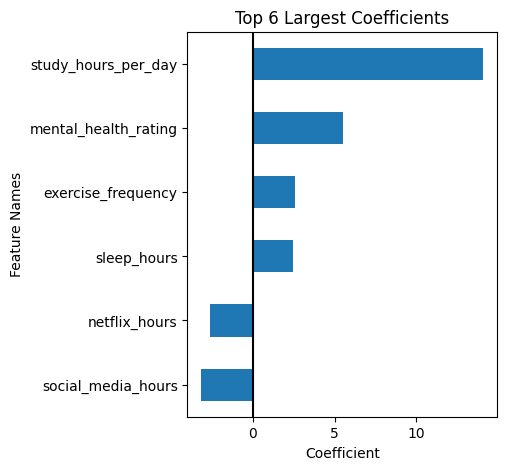

In [ ]:
ax = plot_coeffs(coeffs, top_n=6)

The coefficients represent the **impact of each feature** on the predicted exam score. Positive values indicate a **positive relationship**, while negative values indicate a **negative relationship**.

#### **Key Insights**:

* **Most Influential Negative Factors**:

  * **Social Media Hours**: **-3.13** — More time spent on social media reduces the predicted exam score.
  * **Netflix Hours**: **-2.59** — Similar to social media, higher Netflix usage also decreases the predicted score.
  * **Diet Quality (Good)**: **-0.39** — Students with a "Good" diet tend to score slightly lower than those with a "Fair" or "Poor" diet.
  * **Gender (Female)**: **-0.38** — Female students score slightly lower, though this is likely due to other contributing factors.

* **Most Influential Positive Factors**:

  * **Parental Education (Bachelor)**: **+0.42** — Having a parent with a Bachelor's degree increases the exam score.
  * **Age**: **+0.08** — Older students tend to have slightly higher scores.
  * **Internet Quality (Average)**: **+0.11** — Better internet quality is associated with slightly higher scores.

* **Other Notable Features**:

  * **Part-time Job (Yes)**: **+0.08** — Students with part-time jobs tend to score slightly higher, which could reflect better time management or responsibility.
  * **Parental Education (Master)**: **-0.22** — A Master's degree for parents is negatively correlated with the score, though it is a weaker effect.
  * **Extracurricular Participation (Yes)**: **-0.04** — Participation in extracurricular activities slightly decreases the predicted score, possibly due to time spent outside studying.

#### **Conclusion**:

* **Social media and Netflix usage** have the strongest negative impact on exam performance, while **parental education level** (particularly Bachelor’s degrees) shows a positive impact.
* **Diet quality, gender, and part-time job** have moderate effects, suggesting that lifestyle and family background factors are influential, but not as strong as study habits or media consumption.

### Model 2: Random Forest Regressor

In [ ]:
rf = RandomForestRegressor(random_state=42)
rf_pipe = make_pipeline(preprocessor, rf)
rf_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['gender', 'part_time_job', 'diet_quality', 'parental_education_level',
       'internet_quality', 'extracurricular_participation'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=42))])

In [ ]:
evaluate_regression(rf_pipe, X_train, y_train, X_test, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 1.930
- MSE = 5.770
- RMSE = 2.402
- R^2 = 0.980

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 5.130
- MSE = 42.804
- RMSE = 6.542
- R^2 = 0.841


* **Training Performance**: The **training metrics** are excellent, with an **R²** of **0.980**, indicating that the model explains 98% of the variance in the training data. The **error values** (MAE, RMSE) are also quite low, suggesting the model is fitting very well to the training set.

* **Test Performance**: The **test metrics** show a noticeable drop:

  * **R²** on test data is **0.841**, still quite good but lower than on the training set. This drop suggests **overfitting**, meaning the model is performing well on training data but not generalizing as well to unseen data.
  * **MAE and RMSE** on the test data are significantly higher, indicating the model's predictions are less accurate on the test set compared to training.


In [ ]:
rf_pipe.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('num', StandardScaler(),
                                    Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
          'attendance_percentage', 'sleep_hours', 'exercise_frequency',
          'mental_health_rating'],
         dtype='object')),
                                   ('cat',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(strategy='most_frequent')),
                                                    ('onehotencoder',
                                                     OneHotEncoder(handle_unknown='ignore',
                                                                   sparse_output=False))]),
                                    Index(['gender', 'part_time_job', 'diet_quality', 'parental_education_level',
          'internet_quality', 'extracurricular_participation'],
   

In [ ]:
grid_params_rf = {
    'randomforestregressor__n_estimators': [50, 100, 200],  # Number of trees in the forest
    'randomforestregressor__max_depth': [None, 10, 20, 30],  # Depth of the trees
    'randomforestregressor__min_samples_split': [2, 5, 10],  # Minimum samples to split a node
    'randomforestregressor__min_samples_leaf': [1, 2, 4],  # Minimum samples at each leaf
    'randomforestregressor__max_features': ['auto', 'sqrt', 0.5],  # Number of features to consider at each split
}

In [ ]:
rf_gs = GridSearchCV(rf_pipe, grid_params_rf, cv=3, n_jobs=-1, verbose=1)
rf_gs.fit(X_train, y_train)

Fitting 3 folds for each of 324 candidates, totalling 972 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
324 fits failed out of a total of 972.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
324 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 662, in fit
    self._final_estimator.fit(Xt, y, *

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating'],
      dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(str...
                                       ('randomforestregressor',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'randomforestregressor__max_depth': [None, 10, 20, 30],
                         'randomforestregressor__max_features': ['auto', 'sqrt',
                                                                 0.5],
                         'randomforestregressor__min_samples_leaf': [1, 2, 4],
                         'randomforestregressor__min_samples_split': [2, 5, 10],
                         'randomforestregressor__n_estimators': [50, 100, 200]},
             verbose=1)

In [ ]:
rf_gs.best_params_

{'randomforestregressor__max_depth': 20,
 'randomforestregressor__max_features': 0.5,
 'randomforestregressor__min_samples_leaf': 1,
 'randomforestregressor__min_samples_split': 2,
 'randomforestregressor__n_estimators': 100}

In [ ]:
evaluate_regression(rf_gs.best_estimator_, X_train, y_train, X_test, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 1.938
- MSE = 5.824
- RMSE = 2.413
- R^2 = 0.980

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 4.996
- MSE = 39.021
- RMSE = 6.247
- R^2 = 0.855


### **Random Forest Regression - Tuned Model**:

#### **Best Hyperparameters**:

* **Max Depth**: 20
* **Max Features**: 0.5
* **Min Samples Leaf**: 1
* **Min Samples Split**: 2
* **N Estimators**: 100

**Analysis**:

* The model **performs excellently on the training data** with an **R² of 0.980**, indicating the model explains 98% of the variance in training data.
* However, on **test data**, the **R² drops to 0.855**, showing some **overfitting**—the model fits the training data well but doesn't generalize as strongly to unseen data.
* The **MAE** and **RMSE** on test data are higher than on training, confirming that the model has a higher error when predicting new data.

#### Feature Importance for Random Forest

In [ ]:
rf_pipe.named_steps

{'columntransformer': ColumnTransformer(transformers=[('num', StandardScaler(),
                                  Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
        'attendance_percentage', 'sleep_hours', 'exercise_frequency',
        'mental_health_rating'],
       dtype='object')),
                                 ('cat',
                                  Pipeline(steps=[('simpleimputer',
                                                   SimpleImputer(strategy='most_frequent')),
                                                  ('onehotencoder',
                                                   OneHotEncoder(handle_unknown='ignore',
                                                                 sparse_output=False))]),
                                  Index(['gender', 'part_time_job', 'diet_quality', 'parental_education_level',
        'internet_quality', 'extracurricular_participation'],
       dtype='object'))],
                   verbose_featu

In [ ]:
ct = rf_pipe.named_steps['columntransformer']
feature_names = ct.get_feature_names_out()

In [ ]:
importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=True)

In [ ]:
importances

,0
gender_Other,0.000498
part_time_job_No,0.000963
extracurricular_participation_No,0.000979
part_time_job_Yes,0.001066
extracurricular_participation_Yes,0.001138
gender_Male,0.001395
parental_education_level_Master,0.001453
internet_quality_Poor,0.001479
diet_quality_Poor,0.001602
gender_Female,0.001673


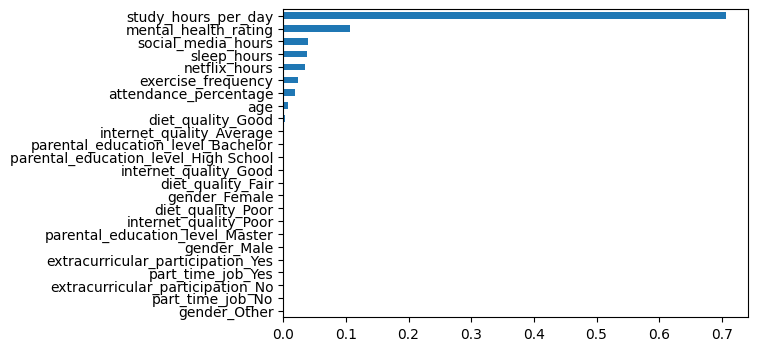

In [ ]:
importances.plot(kind="barh", figsize=(6,4));

The **feature importance** values indicate how much each feature contributes to the model's predictions. A higher value means the feature is more influential in predicting the exam scores.

#### **Top Influential Features**:

* **Study Hours per Day**: **0.7067** — The most important feature, indicating that study time is by far the largest contributor to predicting exam scores.
* **Mental Health Rating**: **0.1073** — A significant factor; students with better mental health ratings tend to score higher.
* **Social Media Hours**: **0.0388** — The time spent on social media has a moderate negative impact on exam performance.
* **Sleep Hours**: **0.0373** — Sleep hours also show some impact, with more sleep slightly correlating to better scores.
* **Netflix Hours**: **0.0352** — Similar to social media, Netflix usage has a moderate negative impact on exam performance.

#### **Moderately Important Features**:

* **Exercise Frequency**: **0.0239** — Physical activity contributes slightly to the exam score.
* **Attendance Percentage**: **0.0189** — Attendance has a small effect on scores.
* **Age**: **0.0082** — Age shows a very minor influence on performance.

#### **Lesser Impact Features**:

* **Diet Quality (Good, Fair, Poor)**: **0.0024 to 0.0016** — Diet quality shows minimal influence on the model's predictions.
* **Internet Quality (Good, Average, Poor)**: **0.0019 to 0.0015** — Internet quality has a small but positive effect, with better internet slightly improving scores.
* **Parental Education Level**: **0.0019 to 0.0015** — The level of parental education shows minimal importance for predicting student scores.
* **Gender (Female, Male, Other)**: **0.0017 to 0.0014** — Gender has a small effect on the model, with female students showing a very slight negative correlation.
* **Extracurricular Participation**: **0.0011 (Yes)** — A minor effect; extracurricular participation shows a small negative influence on scores.
* **Part-time Job (Yes, No)**: **0.0011 to 0.0009** — Having a part-time job slightly impacts the score, but it’s not a major factor.

#### **Conclusion**:

* **Study hours per day** is the **dominant factor** in predicting exam scores, making it the most important feature.
* Other significant factors include **mental health** and **social media hours**, with **exercise, sleep, and Netflix hours** also contributing moderately.
* **Demographic and lifestyle factors** like **gender, diet, and parental education** have **minimal impact** on exam performance according to the Random Forest model.


#### Permutation Importance for Random Forest

In [ ]:
# Permutation importance to evaluate model feature performance
perm_importance_rf = permutation_importance(
    rf_gs.best_estimator_, X_test, y_test, n_repeats=10, random_state=42
)

perm_rf_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm_importance_rf.importances_mean
}).sort_values(by='Importance', ascending=False)

perm_rf_df

,Feature,Importance
2,study_hours_per_day,1.280559
12,mental_health_rating,0.180437
3,social_media_hours,0.044638
9,exercise_frequency,0.043703
7,sleep_hours,0.030936
4,netflix_hours,0.014007
6,attendance_percentage,0.006531
0,age,0.001149
5,part_time_job,0.001074
8,diet_quality,0.000946


Permutation importance measures the effect of randomly shuffling each feature on the model's performance. Higher values indicate a larger impact on prediction accuracy.

#### **Top Influential Features**:

* **Study Hours per Day**: **1.2806** — The most influential feature, indicating a strong effect on the predicted exam scores. The model's performance drops significantly when this feature is shuffled.
* **Mental Health Rating**: **0.1804** — This feature has a notable impact, suggesting that students with better mental health tend to perform better in exams.

#### **Moderate Influences**:

* **Social Media Hours**: **0.0446** — Shuffling social media usage has a moderate effect on performance, reinforcing the negative correlation with exam scores.
* **Exercise Frequency**: **0.0437** — Exercise frequency shows a positive effect on exam scores, contributing moderately to the prediction.
* **Sleep Hours**: **0.0309** — Adequate sleep has a positive but weaker effect on performance.

#### **Lesser Influences**:

* **Netflix Hours**: **0.0140** — Similar to social media, Netflix hours have a minor impact on the exam score prediction.
* **Attendance Percentage**: **0.0065** — A small but non-zero influence on scores.
* **Age**: **0.0011** — Very minimal effect, indicating age does not significantly impact the model's predictions.

#### **Conclusion**:

* **Study hours per day** is by far the **most important** feature, followed by **mental health**.
* **Social media hours** and **exercise frequency** have moderate importance, confirming the effect of lifestyle habits on exam performance.
* **Demographics** (such as **age**, **gender**, and **parental education level**) have minimal to no impact on exam scores based on permutation importance.

### Model 3: KNN Regressor

In [ ]:
knn = KNeighborsRegressor()
knn_pipe = make_pipeline(preprocessor, knn)
knn_pipe.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['gender', 'part_time_job', 'diet_quality', 'parental_education_level',
       'internet_quality', 'extracurricular_participation'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('kneighborsregressor', KNeighborsRegressor())])

In [ ]:
evaluate_regression(knn_pipe, X_train, y_train, X_test, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 6.220
- MSE = 60.390
- RMSE = 7.771
- R^2 = 0.791

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 7.711
- MSE = 99.044
- RMSE = 9.952
- R^2 = 0.633


 **Analysis**:

* **Training Performance**:

  * The **KNN model performs decently on training data**, with an **R² of 0.791**, meaning it explains about **79%** of the variance in the training data. However, the error metrics (MAE, MSE, RMSE) are relatively higher compared to other models like Random Forest or Linear Regression.
* **Test Performance**:

  * The **test data performance drops significantly** with **R² of 0.633**, indicating that the model is not generalizing as well to unseen data.
  * The **MAE and RMSE** on the test set are noticeably higher, showing that the model's predictions are less accurate when applied to new data.

* **Overfitting**: The drop in **R²** and the increase in **MAE** and **RMSE** suggest that the model may be **overfitting** to the training data and not generalizing well to new, unseen data.

In [ ]:
knn_pipe.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('num', StandardScaler(),
                                    Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
          'attendance_percentage', 'sleep_hours', 'exercise_frequency',
          'mental_health_rating'],
         dtype='object')),
                                   ('cat',
                                    Pipeline(steps=[('simpleimputer',
                                                     SimpleImputer(strategy='most_frequent')),
                                                    ('onehotencoder',
                                                     OneHotEncoder(handle_unknown='ignore',
                                                                   sparse_output=False))]),
                                    Index(['gender', 'part_time_job', 'diet_quality', 'parental_education_level',
          'internet_quality', 'extracurricular_participation'],
   

In [ ]:
# Define the parameter grid for KNN in the pipeline
grid_params_knn = {
    'kneighborsregressor__n_neighbors': [3, 5, 7, 10, 15],  # Number of neighbors to use
    'kneighborsregressor__weights': ['uniform', 'distance'],  # Weight function used in prediction
    'kneighborsregressor__metric': ['euclidean', 'manhattan', 'minkowski'],  # Distance metric to use
    'kneighborsregressor__leaf_size': [20, 30, 40, 50],  # Leaf size for the KDTree or BallTree
}

In [ ]:
knn_gs = GridSearchCV(knn_pipe, grid_params_knn, cv=3, n_jobs=-1, verbose=1)
knn_gs.fit(X_train, y_train)

Fitting 3 folds for each of 120 candidates, totalling 360 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating'],
      dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(str...
      dtype='object'))],
                                                          verbose_feature_names_out=False)),
                                       ('kneighborsregressor',
                                        KNeighborsRegressor())]),
             n_jobs=-1,
             param_grid={'kneighborsregressor__leaf_size': [20, 30, 40, 50],
                         'kneighborsregressor__metric': ['euclidean',
                                                         'manhattan',
                                                         'minkowski'],
                         'kneighborsregressor__n_neighbors': [3, 5, 7, 10, 15],
                         'kneighborsregressor__weights': ['uniform',
                                                          'distance']},
             verbose=1)

In [ ]:
knn_gs.best_params_

{'kneighborsregressor__leaf_size': 20,
 'kneighborsregressor__metric': 'euclidean',
 'kneighborsregressor__n_neighbors': 10,
 'kneighborsregressor__weights': 'distance'}

In [ ]:
evaluate_regression(knn_gs.best_estimator_, X_train, y_train, X_test, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 0.000
- MSE = 0.000
- RMSE = 0.000
- R^2 = 1.000

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 7.239
- MSE = 88.559
- RMSE = 9.411
- R^2 = 0.671


#### **Best Hyperparameters**:

* **Leaf Size**: 20
* **Metric**: Euclidean
* **Number of Neighbors**: 10
* **Weights**: Distance

**Analysis**:

* **Overfitting Detected**: The **perfect performance** on the training data (**R² = 1.000**) suggests that the model is **overfitting**. This is because the model predicts training data with no error, but performs poorly on unseen data, as indicated by the **R² = 0.671** on the test data.
* **Test Data Performance**: The **MAE**, **MSE**, and **RMSE** on the test data are significantly higher than those on the training data, further confirming overfitting.


## Model Comparison

In [ ]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'KNN', 'Best KNN'],
    'MAE': [6.220, 4.996, 7.239, 7.239],
    'MSE': [60.390, 39.021, 99.044, 88.559],
    'RMSE': [7.771, 6.247, 9.952, 9.411],
    'R²': [0.791, 0.855, 0.633, 0.671]
})

results

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,6.220,60.390,7.771,0.791
1,Random Forest,4.996,39.021,6.247,0.855
2,KNN,7.239,99.044,9.952,0.633
3,Best KNN,7.239,88.559,9.411,0.671


## **Final Model Selection Justification**:

After evaluating **Linear Regression**, **Random Forest**, and **KNN**, the following points guided the final selection:

#### **1. Performance**:

* **Random Forest** had the best performance, with an **R² of 0.855** on the test data, showing strong generalization.
* **Linear Regression** performed well but didn’t capture the data’s complexity like Random Forest.
* **KNN** showed **overfitting** with **R² of 1.000** on training data and a **drop to 0.671** on test data.

#### **2. Overfitting**:

* **KNN** overfitted, while **Random Forest** provided a more balanced performance, making it the better choice.

#### **3. Robustness**:

* **Random Forest** is robust and handles non-linear relationships effectively, while **KNN** struggled with generalization.

#### **4. Conclusion**:

* **Random Forest** was selected as the final model due to its **strong generalization**, **high accuracy**, and **robustness** to different data patterns.

In [ ]:
final_model = rf_gs.best_estimator_
final_model.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours',
       'attendance_percentage', 'sleep_hours', 'exercise_frequency',
       'mental_health_rating'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['gender', 'part_time_job', 'diet_quality', 'parental_education_level',
       'internet_quality', 'extracurricular_participation'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('randomforestregressor',
                 RandomForestRegressor(max_depth=20, max_features=0.5,
                                       random_state=42))])